# AUDA Combined Benchmark

Compares **Baseline** vs **AUDA** preprocessing across datasets, using two classifiers:
**RandomForestClassifier** and **SVM (RBF kernel)**.

| Category | Shape rule |
|---|---|
| `small` | < 200 rows |
| `tall` | > 800 rows |
| `wide` | < 200 rows, > 20 cols |
| `wide_tall` | > 800 rows, > 14 cols |

**Improvements over original notebook:**
- RF + SVM dual evaluation with separate FeatureTransformer scaling
- Explicit 4-stage AUDA tracking (profile → missing → anomaly → features)
- Partial-failure recovery: stage stats are preserved even if later stages fail
- Saturation skip: if baseline AUC ≥ 0.95, AUDA preprocessing is skipped for ML
- LLM-powered suggestions via Groq (add `GROQ_API_KEY` to `.env`)

In [1]:
import sys, os, json, time, warnings
warnings.filterwarnings('ignore')

from pathlib import Path

REPO_ROOT = os.path.abspath('..')
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.svm import SVC

from auto_eda_agent import AUDA, FeatureTransformer
from auto_eda_agent.profiler import DataProfiler

print('Imports OK')
print(f'Repo root: {REPO_ROOT}')

Imports OK
Repo root: c:\Nicholas\Semester 6\BIgData\fp-dustin-1\auto-eda-agent


In [2]:
# ── Load .env (no extra dependency needed) ────────────────────────────────
def _load_env(search_paths=('.env', '../.env')):
    for path in search_paths:
        env_file = Path(path)
        if env_file.exists():
            for line in env_file.read_text(encoding='utf-8').splitlines():
                line = line.strip()
                if line and not line.startswith('#') and '=' in line:
                    k, v = line.split('=', 1)
                    os.environ.setdefault(k.strip(), v.strip().strip('"').strip("'"))
            print(f'Loaded .env from: {env_file.resolve()}')
            return
    print('.env not found — using system environment variables only')

_load_env()

# ── Output + dataset paths ────────────────────────────────────────────────
OUTPUT_DIR   = 'auda_benchmark_2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

DATASETS_DIR = '../auda_datasets/datasets'
CONFIG_PATH  = os.path.join(DATASETS_DIR, 'config.json')

# ── LLM Support via Groq ──────────────────────────────────────────────────
# Set GROQ_API_KEY in .env to enable LLM-powered feature suggestions.
# Copy example.env → .env and add your key (free at https://console.groq.com).
GROQ_API_KEY = os.environ.get('GROQ_API_KEY', '').strip()
USE_LLM      = bool(GROQ_API_KEY)

if USE_LLM:
    try:
        from auto_eda_agent import GroqProvider
        _llm_provider = GroqProvider(api_key=GROQ_API_KEY)
        print('LLM mode: Groq provider loaded — suggestions will include [LLM] items')
    except Exception as _e:
        print(f'LLM mode: failed ({_e}) — falling back to rule-based')
        USE_LLM, _llm_provider = False, None
else:
    _llm_provider = None
    print('LLM mode: disabled (add GROQ_API_KEY to .env to enable)')

# ── Tuning knobs ──────────────────────────────────────────────────────────
# If baseline cross-val AUC >= this threshold, skip AUDA preprocessing for ML.
# Set to 0.0 to always run AUDA preprocessing regardless of baseline strength.
SATURATION_THRESHOLD = 0.95

ROW_CAP = 20_000  # cap large datasets before SVM training

# ── Dataset registry ──────────────────────────────────────────────────────
with open(CONFIG_PATH) as f:
    full_registry = json.load(f)

TEST_MODE        = False   # True → limit to DATASETS_PER_CAT per category (fast check)
DATASETS_PER_CAT = 2

if TEST_MODE:
    seen, registry = {}, []
    for entry in full_registry:
        cat = entry['file'].split('/')[0]
        if seen.get(cat, 0) < DATASETS_PER_CAT:
            registry.append(entry)
            seen[cat] = seen.get(cat, 0) + 1
    print(f'TEST MODE: {len(registry)} datasets ({DATASETS_PER_CAT} per category)')
else:
    registry = full_registry
    print(f'FULL MODE: {len(registry)} datasets')

print(f'Output folder : {os.path.abspath(OUTPUT_DIR)}')
print(f'Datasets root : {os.path.abspath(DATASETS_DIR)}')
pd.DataFrame(registry)[['file', 'target']]

Loaded .env from: C:\Nicholas\Semester 6\BIgData\fp-dustin-1\auto-eda-agent\.env
LLM mode: Groq provider loaded — suggestions will include [LLM] items
FULL MODE: 39 datasets
Output folder : c:\Nicholas\Semester 6\BIgData\fp-dustin-1\auto-eda-agent\auda_benchmark_2\auda_benchmark_2
Datasets root : c:\Nicholas\Semester 6\BIgData\fp-dustin-1\auto-eda-agent\auda_datasets\datasets


,file,target
0,tall/titanic.csv,Survived
1,tall/stroke.csv,stroke
2,tall/weatheraus.csv,RainTomorrow
3,tall/heart_disease.csv,target
4,tall/cardio_disease.csv,cardio
5,tall/diabetes_2023.csv,diabetes
6,tall/churn_modelling.csv,Exited
7,tall/bank_marketing.csv,y
8,tall/adult_census.csv,income
9,tall/obesity_risk.csv,NObeyesdad


In [3]:
# ── Target encoder ────────────────────────────────────────────────────────
def safe_encode_target(y):
    le = LabelEncoder()
    return pd.Series(le.fit_transform(y.fillna('__nan__').astype(str)), name=y.name)


# ── Categorical encoder (shared by both pipelines) ────────────────────────
def encode_categoricals(X_train, X_test):
    cat_cols = X_train.select_dtypes(exclude='number').columns.tolist()
    num_cols = X_train.select_dtypes(include='number').columns.tolist()
    if not cat_cols:
        return (X_train[num_cols].reset_index(drop=True),
                X_test[num_cols].reset_index(drop=True))
    for col in cat_cols:
        X_train[col] = X_train[col].fillna('Unknown').astype(str)
        X_test[col]  = X_test[col].fillna('Unknown').astype(str)
    enc     = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    cat_tr  = pd.DataFrame(enc.fit_transform(X_train[cat_cols]), columns=cat_cols)
    cat_te  = pd.DataFrame(enc.transform(X_test[cat_cols]),      columns=cat_cols)
    X_tr    = pd.concat([X_train[num_cols].reset_index(drop=True), cat_tr], axis=1)
    X_te    = pd.concat([X_test[num_cols].reset_index(drop=True),  cat_te], axis=1)
    return X_tr, X_te


# ── Baseline: SimpleImputer(mean/mode) + OrdinalEncoder ──────────────────
def run_baseline(X_train, X_test):
    X_tr, X_te = X_train.copy(), X_test.copy()
    drop_cols   = X_tr.columns[X_tr.isnull().mean() >= 0.6].tolist()
    X_tr = X_tr.drop(columns=drop_cols)
    X_te = X_te.drop(columns=drop_cols, errors='ignore')
    num_cols = X_tr.select_dtypes(include='number').columns.tolist()
    cat_cols = X_tr.select_dtypes(exclude='number').columns.tolist()
    if num_cols:
        imp = SimpleImputer(strategy='mean')
        X_tr[num_cols] = imp.fit_transform(X_tr[num_cols])
        X_te[num_cols] = imp.transform(X_te[num_cols])
    if cat_cols:
        imp = SimpleImputer(strategy='most_frequent')
        X_tr[cat_cols] = imp.fit_transform(X_tr[cat_cols])
        X_te[cat_cols] = imp.transform(X_te[cat_cols])
    return encode_categoricals(X_tr, X_te)


# ── AUDA: explicit 4-stage pipeline with per-stage tracking ──────────────
def run_auda_stages(X_train, y_train):
    """Run AUDA profile → missing → anomaly → features with stage tracking.

    Returns (cleaned_X, y_aligned, agent, stats_dict).
    stats_dict['stages_completed'] shows how far we got even on partial failure.
    """
    X_in = X_train.copy().reset_index(drop=True)
    y_in = pd.Series(
        y_train.values if hasattr(y_train, 'values') else list(y_train),
        dtype='int64',
    )
    stats = {
        'stages_completed': 0, 'auda_skipped': False,
        'duplicate_rows': None, 'missing_handled': 0, 'cols_dropped': 0,
        'rows_before': len(X_in), 'rows_after': len(X_in), 'rows_dropped': 0,
        'iqr_outliers': 0, 'iso_anomalies': 0,
        'n_suggestions': 0, 'n_rec_cols': 0,
    }

    agent = AUDA(X_in, verbose=False, llm_provider=_llm_provider)

    # Stage 1 — Profile
    agent.profile_data()
    stats['stages_completed'] = 1
    p = agent.profile_report_
    stats['duplicate_rows'] = p.get('duplicate_rows', 0)

    # Stage 2 — Handle missing
    agent.handle_missing()
    stats['stages_completed'] = 2
    m    = agent.missing_report_ or {}
    smap = m.get('strategy_map', {})
    stats['missing_handled'] = sum(1 for v in smap.values() if v != 'no_action')
    stats['cols_dropped']    = sum(1 for v in smap.values() if v == 'drop_column')

    # Stage 3 — Anomaly detection
    agent.detect_anomalies()
    stats['stages_completed'] = 3
    a   = agent.anomaly_report_ or {}
    iqr = a.get('iqr', {})
    iso = a.get('isolation_forest', {})
    stats['iqr_outliers']  = sum(
        v.get('n_outliers', 0) for v in iqr.values() if isinstance(v, dict))
    stats['iso_anomalies'] = (
        iso.get('n_anomalies', 0)
        if isinstance(iso, dict) and 'error' not in iso else 0
    )

    # Stage 4 — Feature recommendations
    agent.recommend_features()
    stats['stages_completed'] = 4
    fr = agent.feature_report_ or []
    stats['n_suggestions'] = sum(len(r.get('suggestions', [])) for r in fr)
    stats['n_rec_cols']    = len(fr)

    # Align y with rows that survived AUDA cleaning
    cleaned_X = agent.cleaned_df_.copy()
    y_aligned  = y_in[cleaned_X.index]
    stats['rows_after']   = len(cleaned_X)
    stats['rows_dropped'] = stats['rows_before'] - stats['rows_after']

    cleaned_X = cleaned_X.reset_index(drop=True)
    y_aligned  = y_aligned.reset_index(drop=True)

    return cleaned_X, y_aligned, agent, stats


# ── Apply FeatureTransformer to AUDA-cleaned data ────────────────────────
def apply_feature_transformer(cleaned_X, y_aligned, X_test, scale=False):
    """Fit FeatureTransformer on cleaned training data, transform aligned test set.

    scale=False → tree models (RF).  scale=True → distance-sensitive models (SVM).
    """
    keep_cols = [c for c in cleaned_X.columns if c in X_test.columns]
    X_te_c    = X_test[keep_cols].copy()

    # Fill test-set missings using training statistics
    for col in cleaned_X.select_dtypes(include='number').columns:
        if col in X_te_c.columns and X_te_c[col].isnull().any():
            X_te_c[col] = X_te_c[col].fillna(cleaned_X[col].median())
    for col in cleaned_X.select_dtypes(exclude='number').columns:
        if col in X_te_c.columns and X_te_c[col].isnull().any():
            mode_val = cleaned_X[col].mode()
            X_te_c[col] = X_te_c[col].fillna(
                mode_val.iloc[0] if len(mode_val) else 'Unknown')

    prof = DataProfiler(cleaned_X)
    prof.detect_column_types()
    ft = FeatureTransformer(
        cleaned_X, profiler=prof,
        skew_threshold=1.0, iqr_k=5.0, scale=scale,
        frequency_encode_threshold=20,
    )
    X_tr_t = ft.fit_transform()
    X_te_t = ft.transform(X_te_c)

    X_tr_enc, X_te_enc = encode_categoricals(X_tr_t.copy(), X_te_t.copy())
    return X_tr_enc, y_aligned, X_te_enc


# ── Train model and compute metrics ──────────────────────────────────────
def evaluate(X_train, y_train, X_test, y_test, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    all_y  = np.concatenate([
        y_train.values if hasattr(y_train, 'values') else np.array(y_train),
        y_test.values  if hasattr(y_test,  'values') else np.array(y_test),
    ])
    n_cls = len(np.unique(all_y))
    acc   = accuracy_score(y_test, y_pred)
    f1    = f1_score(y_test, y_pred,
                     average='binary' if n_cls == 2 else 'weighted',
                     zero_division=0)
    try:
        auc = (
            roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
            if n_cls == 2 else
            roc_auc_score(y_test, model.predict_proba(X_test),
                          multi_class='ovr', average='macro')
        )
    except Exception:
        auc = float('nan')
    return {'accuracy': acc, 'f1': f1, 'auc': auc, 'n_train': len(X_train)}


print('Helper functions ready.')
print(f'LLM mode           : {"ON — Groq" if USE_LLM else "OFF — rule-based only"}')
print(f'Saturation threshold: {SATURATION_THRESHOLD}')

Helper functions ready.
LLM mode           : ON — Groq
Saturation threshold: 0.95


## Benchmark Loop

For each dataset:
1. **AUDA 4-stage EDA** — explicit stages with per-stage stats tracking
2. **Saturation check** — 3-fold CV on baseline; if AUC ≥ 0.95 skip AUDA preprocessing
3. **RF evaluation** — `scale=False` (tree-appropriate FeatureTransformer)
4. **SVM evaluation** — `scale=True` (distance-sensitive FeatureTransformer)

Targets with > 20 unique values are skipped (regression). Datasets < 40 rows are skipped.

In [4]:
results      = []
feature_recs = []
TOTAL        = len(registry)

RF_MODEL  = lambda: RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
SVM_MODEL = lambda: SVC(kernel='rbf', probability=True, random_state=42)

_NAN = float('nan')
_ML_DEFAULTS = dict(
    rf_status=None,  rf_base_auc=_NAN, rf_auda_auc=_NAN,
    rf_base_acc=_NAN, rf_auda_acc=_NAN, rf_base_f1=_NAN, rf_auda_f1=_NAN,
    rf_delta_auc=_NAN, rf_delta_acc=_NAN, rf_delta_f1=_NAN, rf_winner=None,
    svm_status=None, svm_base_auc=_NAN, svm_auda_auc=_NAN,
    svm_base_acc=_NAN, svm_auda_acc=_NAN, svm_base_f1=_NAN, svm_auda_f1=_NAN,
    svm_delta_auc=_NAN, svm_delta_acc=_NAN, svm_delta_f1=_NAN, svm_winner=None,
)

for idx, entry in enumerate(registry, 1):
    fname    = entry['file']
    fp       = os.path.join(DATASETS_DIR, fname)
    tgt      = entry['target']
    category = fname.split('/')[0]
    name     = os.path.basename(fname)
    t0       = time.time()

    row = {'dataset': name, 'file': fname, 'category': category, 'target': tgt,
           'status': 'pending', 'stages_completed': 0, **_ML_DEFAULTS}

    print(f'[{idx:02d}/{TOTAL}] {fname:<52}', end='', flush=True)

    try:
        if not os.path.exists(fp):
            row['status'] = 'missing'
            results.append(row); print('SKIP - file not found'); continue

        df = pd.read_csv(fp, low_memory=False)
        row['n_rows'] = df.shape[0]
        row['n_cols'] = df.shape[1]

        if len(df) > ROW_CAP:
            df = df.sample(n=ROW_CAP, random_state=42).reset_index(drop=True)
            row['sampled'] = True

        # Case-insensitive target lookup
        col_lower = {c.strip().lower(): c for c in df.columns}
        if tgt not in df.columns:
            if tgt.lower() in col_lower:
                tgt = col_lower[tgt.lower()]
            else:
                row['status'] = 'no_target'
                results.append(row); print('SKIP - target not found'); continue

        X         = df.drop(columns=[tgt])
        y_raw     = df[tgt]
        n_classes = int(y_raw.dropna().nunique())
        row['n_classes'] = n_classes

        if n_classes < 2:
            row['status'] = 'single_class'
            results.append(row); print('SKIP - only 1 class'); continue
        if n_classes > 20:
            row['status'] = 'too_many_classes'
            results.append(row)
            print(f'SKIP - {n_classes} classes (regression?)'); continue
        if len(df) < 40:
            row['status'] = 'too_small'
            results.append(row); print('SKIP - dataset too small (<40 rows)'); continue

        y = safe_encode_target(y_raw)

        try:
            X_tr, X_te, y_tr, y_te = train_test_split(
                X, y, test_size=0.2, random_state=42, stratify=y)
        except ValueError:
            X_tr, X_te, y_tr, y_te = train_test_split(
                X, y, test_size=0.2, random_state=42)

        # ── Stage 1-4: AUDA EDA (always runs for stats + recommendations) ──
        auda_ok   = False
        cleaned_X = y_aligned = agent = None
        stage_stats = {}
        try:
            cleaned_X, y_aligned, agent, stage_stats = run_auda_stages(
                X_tr.copy(), y_tr.copy())
            row.update(stage_stats)
            auda_ok = True
        except Exception as auda_exc:
            row['stages_completed'] = stage_stats.get('stages_completed', 0)
            row['auda_error'] = str(auda_exc)[:150]

        # Collect per-column feature recommendations
        if agent is not None:
            for rec in (agent.feature_report_ or []):
                for sug in rec.get('suggestions', []):
                    is_llm = sug.startswith('[LLM] ')
                    feature_recs.append({
                        'dataset':    name,       'category':   category,
                        'column':     rec['column'], 'col_type': rec['type'],
                        'suggestion': sug[6:] if is_llm else sug,
                        'source':     'LLM' if is_llm else 'rule',
                    })

        # ── Baseline preprocessing (shared for RF and SVM) ─────────────────
        Xb_tr, Xb_te = run_baseline(X_tr.copy(), X_te.copy())

        # ── Saturation check: skip AUDA FT if baseline already strong ──────
        use_auda_preprocess = auda_ok
        if auda_ok and SATURATION_THRESHOLD > 0:
            try:
                scoring = 'roc_auc' if n_classes == 2 else 'roc_auc_ovr'
                base_cv = cross_val_score(
                    RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1),
                    Xb_tr, y_tr, cv=3, scoring=scoring,
                ).mean()
                if base_cv >= SATURATION_THRESHOLD:
                    use_auda_preprocess = False
                    row['auda_skipped_ml'] = True
            except Exception:
                pass

        # ── FeatureTransformer: RF (no scale) and SVM (scaled) ─────────────
        if use_auda_preprocess:
            try:
                Xa_tr_rf,  y_a_rf,  Xa_te_rf  = apply_feature_transformer(
                    cleaned_X, y_aligned, X_te.copy(), scale=False)
                Xa_tr_svm, y_a_svm, Xa_te_svm = apply_feature_transformer(
                    cleaned_X, y_aligned, X_te.copy(), scale=True)
            except Exception as ft_exc:
                row['ft_error'] = str(ft_exc)[:150]
                use_auda_preprocess = False

        if not use_auda_preprocess:
            Xa_tr_rf,  y_a_rf,  Xa_te_rf  = Xb_tr, y_tr, Xb_te
            Xa_tr_svm, y_a_svm, Xa_te_svm = Xb_tr, y_tr, Xb_te

        # ── RF Evaluation ────────────────────────────────────────────────────
        try:
            mb_rf = evaluate(Xb_tr,    y_tr,   Xb_te,    y_te, RF_MODEL())
            ma_rf = evaluate(Xa_tr_rf, y_a_rf, Xa_te_rf, y_te, RF_MODEL())
            sat_tag = '(saturated)' if not use_auda_preprocess else ''
            row.update({
                'rf_status':    f'ok{sat_tag}',
                'rf_base_acc':   round(mb_rf['accuracy'], 4),
                'rf_base_f1':    round(mb_rf['f1'],       4),
                'rf_base_auc':   round(mb_rf['auc'],      4),
                'rf_auda_acc':   round(ma_rf['accuracy'], 4),
                'rf_auda_f1':    round(ma_rf['f1'],       4),
                'rf_auda_auc':   round(ma_rf['auc'],      4),
                'rf_delta_acc':  round(ma_rf['accuracy'] - mb_rf['accuracy'], 4),
                'rf_delta_f1':   round(ma_rf['f1']       - mb_rf['f1'],       4),
                'rf_delta_auc':  round(ma_rf['auc']      - mb_rf['auc'],      4),
                'rf_winner':    'AUDA' if ma_rf['auc'] >= mb_rf['auc'] else 'Baseline',
                'rf_base_n':     mb_rf['n_train'],
                'rf_auda_n':     ma_rf['n_train'],
            })
        except Exception as e:
            row['rf_status'] = f'error: {e}'

        # ── SVM Evaluation ───────────────────────────────────────────────────
        try:
            mb_svm  = evaluate(Xb_tr,     y_tr,    Xb_te,     y_te, SVM_MODEL())
            ma_svm  = evaluate(Xa_tr_svm, y_a_svm, Xa_te_svm, y_te, SVM_MODEL())
            row.update({
                'svm_status':    f'ok{sat_tag}',
                'svm_base_acc':  round(mb_svm['accuracy'], 4),
                'svm_base_f1':   round(mb_svm['f1'],       4),
                'svm_base_auc':  round(mb_svm['auc'],      4),
                'svm_auda_acc':  round(ma_svm['accuracy'], 4),
                'svm_auda_f1':   round(ma_svm['f1'],       4),
                'svm_auda_auc':  round(ma_svm['auc'],      4),
                'svm_delta_acc': round(ma_svm['accuracy'] - mb_svm['accuracy'], 4),
                'svm_delta_f1':  round(ma_svm['f1']       - mb_svm['f1'],       4),
                'svm_delta_auc': round(ma_svm['auc']      - mb_svm['auc'],      4),
                'svm_winner':   'AUDA' if ma_svm['auc'] >= mb_svm['auc'] else 'Baseline',
                'svm_base_n':    mb_svm['n_train'],
                'svm_auda_n':    ma_svm['n_train'],
            })
        except Exception as e:
            row['svm_status'] = f'error: {e}'

        row['status'] = 'ok'
        rf_d   = row.get('rf_delta_auc',  _NAN)
        svm_d  = row.get('svm_delta_auc', _NAN)
        elapsed = round(time.time() - t0, 1)
        rf_icon  = 'UP'   if (not np.isnan(rf_d)  and rf_d  >= 0) else 'DOWN'
        svm_icon = 'UP'   if (not np.isnan(svm_d) and svm_d >= 0) else 'DOWN'
        print(f'RF:{rf_d:+.4f}[{rf_icon}]  SVM:{svm_d:+.4f}[{svm_icon}]  {elapsed}s')

    except Exception as e:
        row['status'] = 'error'
        row['error']  = str(e)[:200]
        print(f'ERROR: {e}')

    row['elapsed_s'] = round(time.time() - t0, 1)
    results.append(row)

n_ok = sum(1 for r in results if r.get('status') == 'ok')
print(f'\n{"=" * 60}')
print(f'Completed             : {n_ok}/{len(results)} successful')
print(f'Feature recs collected: {len(feature_recs):,}')

[01/39] tall/titanic.csv                                    RF:+0.0168[UP]  SVM:+0.3072[UP]  8.9s
[02/39] tall/stroke.csv                                     RF:-0.2507[DOWN]  SVM:+0.1083[UP]  12.4s
[03/39] tall/weatheraus.csv                                 RF:-0.3208[DOWN]  SVM:-0.2415[DOWN]  168.1s
[04/39] tall/heart_disease.csv                              RF:+0.0000[UP]  SVM:+0.0000[UP]  10.1s
[05/39] tall/cardio_disease.csv                             RF:+0.0025[UP]  SVM:+0.1523[UP]  173.5s
[06/39] tall/diabetes_2023.csv                              RF:+0.0000[UP]  SVM:+0.0000[UP]  26.5s
[07/39] tall/churn_modelling.csv                            RF:+0.0116[UP]  SVM:+0.2410[UP]  33.4s
[08/39] tall/bank_marketing.csv                             RF:-0.0000[UP]  SVM:+0.0092[UP]  108.1s
[09/39] tall/adult_census.csv                               RF:-0.0001[DOWN]  SVM:+0.1700[UP]  108.8s
[10/39] tall/obesity_risk.csv                               RF:+0.0000[UP]  SVM:+0.0000[UP]  15.3s

[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'Veggies'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'HvyAlcoholConsump'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'AnyHealthcare'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'NoDocbcCost'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'GenHlth'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'MentHlth'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for re

RF:-0.0000[UP]  SVM:+0.0216[UP]  107.0s
[16/39] wide_tall/employee_attrition.csv                    

[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'Employee ID'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'Age'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'Gender'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'Years at Company'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'Job Role'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'Monthly Income'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaini

RF:-0.0008[DOWN]  SVM:+0.2454[UP]  232.5s
[17/39] wide_tall/mushroom.csv                              

...

RF:+0.0000[UP]  SVM:+0.0000[UP]  5.3s
[38/39] wide/colon_cancer.csv                               

[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'id'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'radius_mean'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'texture_mean'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'perimeter_mean'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'area_mean'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'smoothness_mean'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for re

RF:+0.0000[UP]  SVM:+0.0000[UP]  5.4s
[39/39] wide/urban_land.csv                                 

[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'F1R'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'F1S'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'F2R'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'F2S'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'F3R'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm_recommender - Groq rate limit hit for column 'F3S'. Free tier: 30 RPM / 1,000 RPD. Falling back to rule-based for remaining columns.
[WARNING] auto_eda_agent.llm

RF:+0.0000[UP]  SVM:+0.1524[UP]  6.9s

Completed             : 37/39 successful
Feature recs collected: 4,620


In [5]:
df_res = pd.DataFrame(results)
df_ok  = df_res[df_res['status'] == 'ok'].copy()

not_ok = df_res[df_res['status'] != 'ok'][['dataset', 'category', 'status']]
if len(not_ok):
    print('Non-successful entries:')
    print(not_ok.to_string(index=False))
else:
    print('All entries ran successfully!')

rf_ok  = df_ok['rf_status'].str.startswith('ok', na=False).sum()
svm_ok = df_ok['svm_status'].str.startswith('ok', na=False).sum()
print(f'\n{len(df_ok)} datasets evaluated  |  RF ok: {rf_ok}  |  SVM ok: {svm_ok}')

Non-successful entries:
     dataset category       status
   sonar.csv    small single_class
banknote.csv    small single_class

37 datasets evaluated  |  RF ok: 37  |  SVM ok: 37


## Results Table

Colour gradient on `rf_delta_auc` and `svm_delta_auc`: green = AUDA improved, red = degraded.

In [6]:
from IPython.display import display

disp_cols = [
    'dataset', 'category', 'n_rows', 'n_cols',
    'rf_base_auc', 'rf_auda_auc', 'rf_delta_auc',
    'svm_base_auc', 'svm_auda_auc', 'svm_delta_auc',
    'stages_completed', 'elapsed_s',
]
avail_disp = [c for c in disp_cols if c in df_ok.columns]

styled = (
    df_ok[avail_disp]
    .sort_values(['category', 'dataset'])
    .style
    .format({
        'rf_base_auc':   '{:.4f}', 'rf_auda_auc':   '{:.4f}', 'rf_delta_auc':  '{:+.4f}',
        'svm_base_auc':  '{:.4f}', 'svm_auda_auc':  '{:.4f}', 'svm_delta_auc': '{:+.4f}',
        'elapsed_s':     '{:.0f}s', 'n_rows': '{:,}',
    })
    .background_gradient(subset=['rf_delta_auc'],  cmap='RdYlGn', vmin=-0.05, vmax=0.05)
    .background_gradient(subset=['svm_delta_auc'], cmap='RdYlGn', vmin=-0.05, vmax=0.05)
    .set_caption('Benchmark Results — Baseline vs AUDA  (RF + SVM)')
)
display(styled)

,dataset,category,n_rows,n_cols,rf_base_auc,rf_auda_auc,rf_delta_auc,svm_base_auc,svm_auda_auc,svm_delta_auc,stages_completed,elapsed_s
27,blood_transfusion.csv,small,199,12,0.8626,0.7679,-0.0948,0.5549,0.8132,+0.2582,4,3s
25,ecoli.csv,small,199,9,nan,nan,+nan,nan,nan,+nan,4,3s
21,haberman.csv,small,199,4,0.7962,0.7962,+0.0000,0.6614,0.7774,+0.1160,4,2s
22,heart_cleveland.csv,small,199,9,0.8787,0.8773,-0.0013,0.8587,0.8693,+0.0107,4,3s
20,iris.csv,small,150,6,1.0000,1.0000,+0.0000,1.0000,1.0000,+0.0000,4,2s
28,liver_patient.csv,small,199,11,0.6517,0.6967,+0.0450,0.4567,0.6233,+0.1667,4,3s
24,vertebral.csv,small,199,7,0.9970,0.9970,+0.0000,1.0000,1.0000,+0.0000,4,2s
8,adult_census.csv,tall,"32,561",15,0.9007,0.9007,-0.0001,0.6243,0.7943,+0.1700,4,109s
7,bank_marketing.csv,tall,"41,188",20,0.7680,0.7680,-0.0000,0.6682,0.6775,+0.0092,4,108s
4,cardio_disease.csv,tall,"70,000",13,0.7877,0.7902,+0.0025,0.6463,0.7985,+0.1523,4,174s


## Summary by Category

In [7]:
def _win_rate(x):
    pct = (x > 0).mean() * 100
    return f'{pct:.0f}%'

agg_map = {
    'n_datasets':          ('dataset',          'count'),
    'pipe_4stages':        ('stages_completed', lambda x: int((x == 4).sum())),
    # RF
    'rf_auda_wins':        ('rf_delta_auc',  lambda x: int((x > 0).sum())),
    'rf_win_rate':         ('rf_delta_auc',  _win_rate),
    'rf_mean_base_auc':    ('rf_base_auc',   'mean'),
    'rf_mean_auda_auc':    ('rf_auda_auc',   'mean'),
    'rf_mean_delta_auc':   ('rf_delta_auc',  'mean'),
    'rf_mean_delta_acc':   ('rf_delta_acc',  'mean'),
    'rf_mean_delta_f1':    ('rf_delta_f1',   'mean'),
    # SVM
    'svm_auda_wins':       ('svm_delta_auc', lambda x: int((x > 0).sum())),
    'svm_win_rate':        ('svm_delta_auc', _win_rate),
    'svm_mean_base_auc':   ('svm_base_auc',  'mean'),
    'svm_mean_auda_auc':   ('svm_auda_auc',  'mean'),
    'svm_mean_delta_auc':  ('svm_delta_auc', 'mean'),
    'svm_mean_delta_acc':  ('svm_delta_acc', 'mean'),
    'svm_mean_delta_f1':   ('svm_delta_f1',  'mean'),
    # timing
    'total_elapsed_s':     ('elapsed_s',     'sum'),
}

summary = df_ok.groupby('category').agg(**agg_map).reset_index()
for col in summary.select_dtypes(include='float').columns:
    summary[col] = summary[col].round(4)

sep = '=' * 110
print(sep)
print('  SUMMARY BY CATEGORY')
print(sep)
print(summary.to_string(index=False))

rf_wins  = (df_ok['rf_delta_auc']  > 0).mean() * 100
svm_wins = (df_ok['svm_delta_auc'] > 0).mean() * 100
print(f'\nOverall AUDA win rate  RF : {rf_wins:.0f}%   mean delta AUC: {df_ok["rf_delta_auc"].mean():+.4f}')
print(f'Overall AUDA win rate SVM : {svm_wins:.0f}%   mean delta AUC: {df_ok["svm_delta_auc"].mean():+.4f}')
print(f'Total runtime             : {df_ok["elapsed_s"].sum():.0f}s ({df_ok["elapsed_s"].sum()/60:.1f} min)')

print(f'\n{sep}')
print('  TOP & WORST PER CATEGORY  (ranked by RF delta_auc)')
print(sep)
for cat in sorted(df_ok['category'].unique()):
    sub = df_ok[df_ok['category'] == cat].dropna(subset=['rf_delta_auc'])
    if sub.empty: continue
    best  = sub.loc[sub['rf_delta_auc'].idxmax()]
    worst = sub.loc[sub['rf_delta_auc'].idxmin()]
    print(f'\n  [{cat.upper()}]  ({len(sub)} datasets)')
    print(f'  BEST  : {best["dataset"]:<35}  '
          f'RF d={best["rf_delta_auc"]:+.4f}  SVM d={best.get("svm_delta_auc", float("nan")):+.4f}')
    print(f'  WORST : {worst["dataset"]:<35}  '
          f'RF d={worst["rf_delta_auc"]:+.4f}  SVM d={worst.get("svm_delta_auc", float("nan")):+.4f}')

  SUMMARY BY CATEGORY
 category  n_datasets  pipe_4stages  rf_auda_wins rf_win_rate  rf_mean_base_auc  rf_mean_auda_auc  rf_mean_delta_auc  rf_mean_delta_acc  rf_mean_delta_f1  svm_auda_wins svm_win_rate  svm_mean_base_auc  svm_mean_auda_auc  svm_mean_delta_auc  svm_mean_delta_acc  svm_mean_delta_f1  total_elapsed_s
    small           7             7             1         14%            0.8644            0.8558            -0.0085            -0.0179           -0.0406              4          57%             0.7553             0.8472              0.0919              0.0143             0.1138             18.0
     tall          10            10             3         30%            0.8716            0.8175            -0.0541            -0.0052           -0.0193              6          60%             0.6896             0.7642              0.0746              0.0494             0.0170            665.1
     wide          10            10             2         20%            0.8429           

## Visualisations

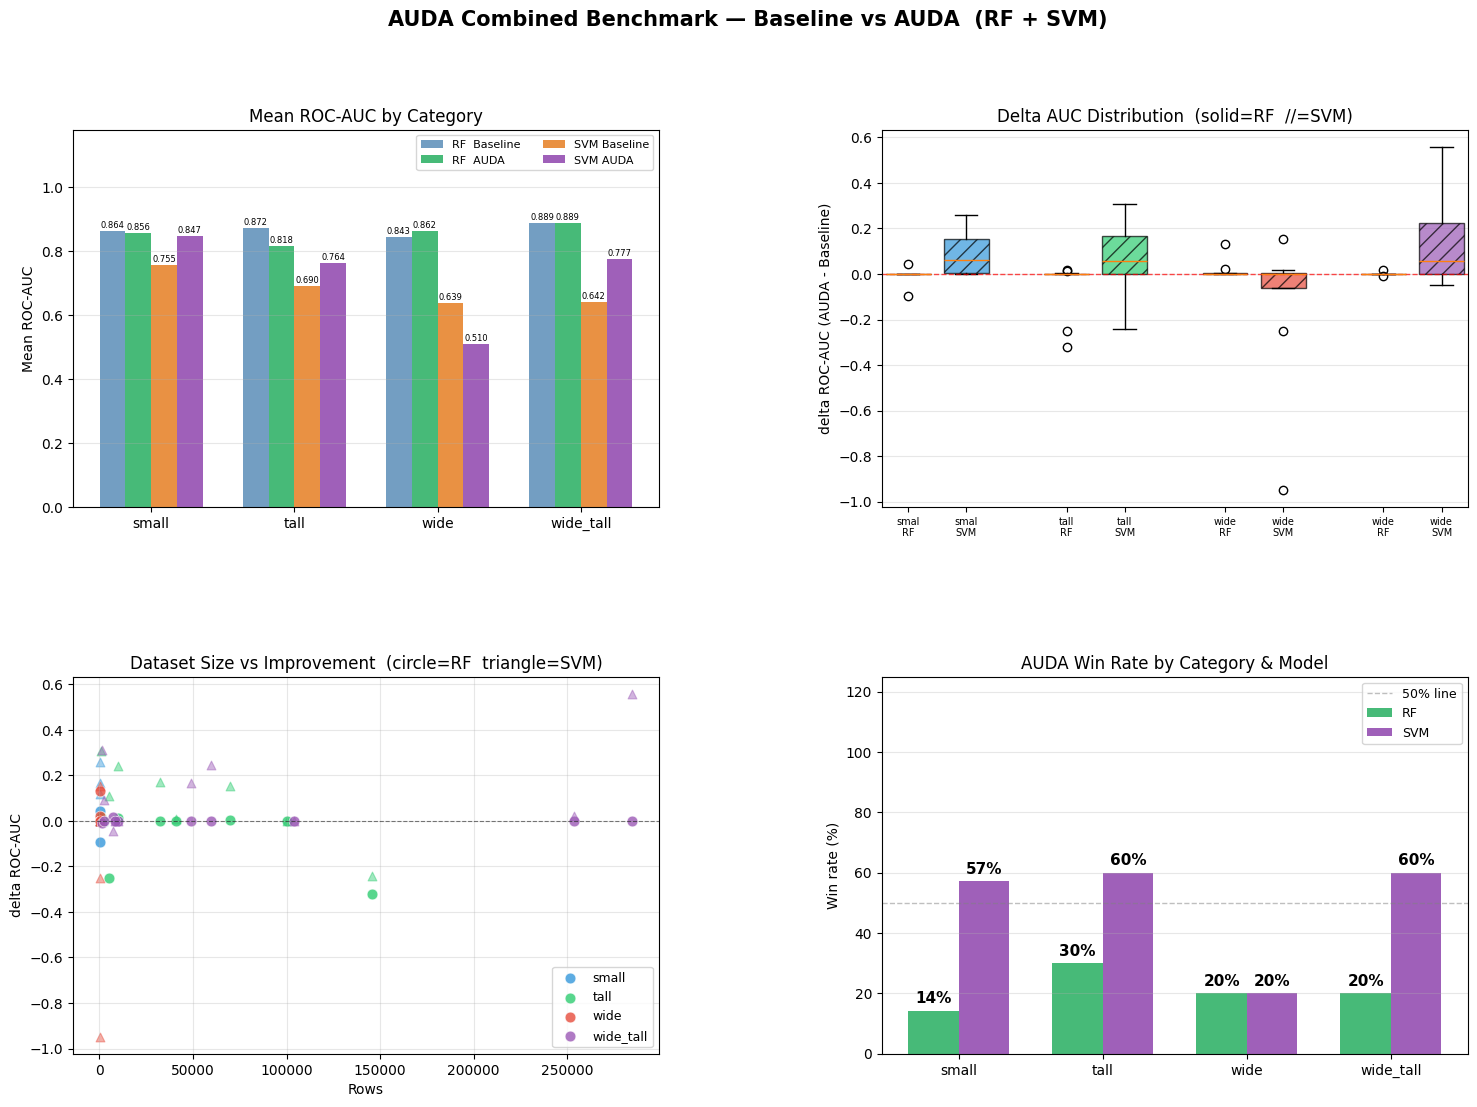

Chart saved -> auda_benchmark_2\benchmark_results_combined.png


In [8]:
CAT_ORDER  = ['small', 'tall', 'wide', 'wide_tall']
CAT_COLORS = {'small': '#3498DB', 'tall': '#2ECC71', 'wide': '#E74C3C', 'wide_tall': '#9B59B6'}
CATS       = [c for c in CAT_ORDER if c in df_ok['category'].values]

fig = plt.figure(figsize=(18, 12))
fig.suptitle('AUDA Combined Benchmark — Baseline vs AUDA  (RF + SVM)', fontsize=15, fontweight='bold')
gs  = gridspec.GridSpec(2, 2, hspace=0.45, wspace=0.38)

# ── Chart 1: Mean AUC grouped bar (4 bars per category) ──────────────────
ax1 = fig.add_subplot(gs[0, 0])
x, w = np.arange(len(CATS)), 0.18
_means = lambda key: [df_ok[df_ok['category'] == c][key].mean() for c in CATS]
bars_cfg = [
    (_means('rf_base_auc'),  'RF  Baseline', '#5B8DB8'),
    (_means('rf_auda_auc'),  'RF  AUDA',     '#27AE60'),
    (_means('svm_base_auc'), 'SVM Baseline', '#E67E22'),
    (_means('svm_auda_auc'), 'SVM AUDA',     '#8E44AD'),
]
for i, (vals, label, color) in enumerate(bars_cfg):
    bars = ax1.bar(x + (i - 1.5) * w, vals, w, label=label, color=color, alpha=0.85)
    for bar in bars:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=6)
ax1.set_xticks(x); ax1.set_xticklabels(CATS, fontsize=10)
ax1.set_ylim(0, 1.18); ax1.set_ylabel('Mean ROC-AUC')
ax1.set_title('Mean ROC-AUC by Category')
ax1.legend(fontsize=8, ncol=2); ax1.grid(axis='y', alpha=0.3)

# ── Chart 2: Delta AUC boxplot — RF vs SVM per category ──────────────────
ax2 = fig.add_subplot(gs[0, 1])
positions, labels_bp, hatches_bp, colors_bp = [], [], [], []
data_bp = []
for i, cat in enumerate(CATS):
    sub = df_ok[df_ok['category'] == cat]
    for j, (key, hatch) in enumerate([('rf_delta_auc', ''), ('svm_delta_auc', '//')]):
        positions.append(i * 3 + j * 1.1)
        labels_bp.append(f'{cat[:4]}\n{"RF" if j == 0 else "SVM"}')
        hatches_bp.append(hatch)
        colors_bp.append(CAT_COLORS.get(cat, '#999'))
        data_bp.append(sub[key].dropna().values)

bp = ax2.boxplot(data_bp, positions=positions, patch_artist=True, widths=0.85)
for patch, color, hatch in zip(bp['boxes'], colors_bp, hatches_bp):
    patch.set_facecolor(color); patch.set_alpha(0.7); patch.set_hatch(hatch)
ax2.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.7)
ax2.set_xticks(positions); ax2.set_xticklabels(labels_bp, fontsize=7)
ax2.set_ylabel('delta ROC-AUC (AUDA - Baseline)')
ax2.set_title('Delta AUC Distribution  (solid=RF  //=SVM)')
ax2.grid(axis='y', alpha=0.3)

# ── Chart 3: Scatter — dataset size vs delta_auc ──────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
for cat in CATS:
    sub = df_ok[df_ok['category'] == cat]
    ax3.scatter(sub['n_rows'], sub['rf_delta_auc'].values,
                label=cat, color=CAT_COLORS.get(cat, '#999'),
                alpha=0.80, s=60, edgecolors='white', linewidths=0.5)
    ax3.scatter(sub['n_rows'], sub['svm_delta_auc'].values,
                color=CAT_COLORS.get(cat, '#999'),
                alpha=0.45, s=40, marker='^',
                edgecolors=CAT_COLORS.get(cat, '#999'), linewidths=0.8)
ax3.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax3.set_xlabel('Rows'); ax3.set_ylabel('delta ROC-AUC')
ax3.set_title('Dataset Size vs Improvement  (circle=RF  triangle=SVM)')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

# ── Chart 4: Win rate — RF vs SVM side-by-side ───────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
x4, w4 = np.arange(len(CATS)), 0.35
_wr = lambda key: [(df_ok[df_ok['category'] == c][key] > 0).mean() * 100 for c in CATS]
rf_wr, svm_wr = _wr('rf_delta_auc'), _wr('svm_delta_auc')
b4a = ax4.bar(x4 - w4 / 2, rf_wr,  w4, label='RF',  color='#27AE60', alpha=0.85)
b4b = ax4.bar(x4 + w4 / 2, svm_wr, w4, label='SVM', color='#8E44AD', alpha=0.85)
for bar, v in list(zip(b4a, rf_wr)) + list(zip(b4b, svm_wr)):
    ax4.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
             f'{v:.0f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax4.axhline(50, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='50% line')
ax4.set_xticks(x4); ax4.set_xticklabels(CATS, fontsize=10)
ax4.set_ylim(0, 125); ax4.set_ylabel('Win rate (%)')
ax4.set_title('AUDA Win Rate by Category & Model')
ax4.legend(fontsize=9); ax4.grid(axis='y', alpha=0.3)

out_png = os.path.join(OUTPUT_DIR, 'benchmark_results_combined.png')
plt.savefig(out_png, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved -> {out_png}')

## Feature Recommendations

Per-column suggestions generated by AUDA's rule engine (and Groq LLM when enabled).

- **source = rule** — built-in heuristics (always available)
- **source = LLM**  — Groq-powered suggestions (requires `GROQ_API_KEY` in `.env`)

In [9]:
from IPython.display import display

df_recs = pd.DataFrame(feature_recs) if feature_recs else pd.DataFrame()

if df_recs.empty:
    print('No feature recommendations collected (run the benchmark loop first).')
else:
    print(f'Total suggestions : {len(df_recs):,}')
    print(f'Unique datasets   : {df_recs["dataset"].nunique()}')
    print(f'Unique columns    : {df_recs["column"].nunique()}')
    if 'source' in df_recs.columns:
        print(f'LLM suggestions   : {(df_recs["source"] == "LLM").sum():,}')
        print(f'Rule suggestions  : {(df_recs["source"] == "rule").sum():,}')
    print('\nSuggestions by column type:')
    print(df_recs.groupby('col_type').size().sort_values(ascending=False).to_string())
    print('\nSample (first 20 rows):')
    display(df_recs.head(20))

Total suggestions : 4,620
Unique datasets   : 37
Unique columns    : 757
LLM suggestions   : 1,259
Rule suggestions  : 3,361

Suggestions by column type:
col_type
numeric        3528
categorical     905
boolean         159
datetime         28

Sample (first 20 rows):


,dataset,category,column,col_type,suggestion,source
0,titanic.csv,tall,PassengerId,numeric,Bin 'PassengerId' into quantile-based buckets ...,rule
1,titanic.csv,tall,PassengerId,numeric,Bin 'PassengerId' into equal-width buckets -> ...,rule
2,titanic.csv,tall,PassengerId,numeric,Consider polynomial features or interactions w...,rule
3,titanic.csv,tall,PassengerId,numeric,is_survivor,LLM
4,titanic.csv,tall,PassengerId,numeric,class_based_id,LLM
5,titanic.csv,tall,PassengerId,numeric,id_range,LLM
6,titanic.csv,tall,PassengerId,numeric,id_prefix,LLM
7,titanic.csv,tall,PassengerId,numeric,id_suffix,LLM
8,titanic.csv,tall,Pclass,numeric,Consider polynomial features or interactions w...,rule
9,titanic.csv,tall,Pclass,numeric,one-hot encoding,LLM


In [10]:
# 1. Per-dataset summary
clean_cols = [
    'dataset', 'category', 'n_rows', 'n_cols', 'n_classes',
    'stages_completed', 'duplicate_rows', 'missing_handled', 'cols_dropped',
    'rows_before', 'rows_after', 'rows_dropped', 'iqr_outliers', 'iso_anomalies',
    'n_suggestions', 'n_rec_cols',
    'rf_status',  'rf_base_acc',  'rf_base_f1',  'rf_base_auc',
    'rf_auda_acc',  'rf_auda_f1',  'rf_auda_auc',
    'rf_delta_acc',  'rf_delta_f1',  'rf_delta_auc',  'rf_winner',
    'svm_status', 'svm_base_acc', 'svm_base_f1', 'svm_base_auc',
    'svm_auda_acc', 'svm_auda_f1', 'svm_auda_auc',
    'svm_delta_acc', 'svm_delta_f1', 'svm_delta_auc', 'svm_winner',
    'elapsed_s', 'status',
]
avail = [c for c in clean_cols if c in df_ok.columns]
p1 = os.path.join(OUTPUT_DIR, 'results_combined_summary.csv')
df_ok[avail].to_csv(p1, index=False)
print(f'Saved -> {p1}  ({len(df_ok)} rows, {len(avail)} cols)')

# 2. Category summary
p2 = os.path.join(OUTPUT_DIR, 'results_combined_by_category.csv')
summary.to_csv(p2, index=False)
print(f'Saved -> {p2}')

# 3. Feature recommendations
if not df_recs.empty:
    p3 = os.path.join(OUTPUT_DIR, 'feature_recommendations_combined.csv')
    df_recs.to_csv(p3, index=False)
    print(f'Saved -> {p3}  ({len(df_recs):,} suggestions)')

# 4. Full raw results (includes skipped / errored datasets)
p4 = os.path.join(OUTPUT_DIR, 'results_combined_all_raw.csv')
df_res.to_csv(p4, index=False)
print(f'Saved -> {p4}  ({len(df_res)} rows total)')

print(f'\nAll outputs in: {os.path.abspath(OUTPUT_DIR)}/')

Saved -> auda_benchmark_2\results_combined_summary.csv  (37 rows, 40 cols)
Saved -> auda_benchmark_2\results_combined_by_category.csv
Saved -> auda_benchmark_2\feature_recommendations_combined.csv  (4,620 suggestions)
Saved -> auda_benchmark_2\results_combined_all_raw.csv  (39 rows total)

All outputs in: c:\Nicholas\Semester 6\BIgData\fp-dustin-1\auto-eda-agent\auda_benchmark_2\auda_benchmark_2/
